In [8]:
import arc
from arc import *
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Latex
import scipy
import pairinteraction as pi
h = scipy.constants.h
epsilon_0 = scipy.constants.epsilon_0
a_0 = scipy.constants.physical_constants['Bohr radius']
e = scipy.constants.e


In [9]:
Rb = arc.Rubidium()
colours = ('orange', 'green', 'red', 'blue')

difs = np.arange(-3, 3)
changes = np.arange(0, 3)

min_n = 40
max_n = 90
ns = np.arange(min_n,max_n)
jps = [(1/2,1/2), (1/2,3/2), (3/2,1/2), (3/2,3/2)]

jp_deltas = []
preferQuantumDefects = True
# C3k coefficients
c3ks = []
w=1
channels = []
num=1
for dif in difs:
    for change1 in changes:
        for change2 in changes:
            jpdelta1 = []
            jpdelta2 = []
    
            for jp in jps:    
            
                delta1 = []
                delta2 = []

                for n in ns:
                    nb = n+dif
                    # Rb lowering n
                    defect_Rb = Rb.getEnergy(n+change1, 1, jp[0], 1/2) - Rb.getEnergy(n, 0, 1/2, 1/2)
                    defect_Rb2 = Rb.getEnergy(nb, 0, 1/2, 1/2) - Rb.getEnergy(nb-change2, 1, jp[1], 1/2)
                    defect = defect_Rb - defect_Rb2
                    delta1.append(defect*1.6e-19/h/1e9)

                    # for Cs lowering n
                    defect_Rb = Rb.getEnergy(n-change1, 1, jp[0], 1/2) - Rb.getEnergy(n, 0, 1/2, 1/2)
                    defect_Rb2 = Rb.getEnergy(nb, 0, 1/2, 1/2) - Rb.getEnergy(nb+change2, 1, jp[1], 1/2)
                    defect = defect_Rb - defect_Rb2
                    delta2.append(defect*1.6e-19/h/1e9)
                
                jpdelta1.append(delta1)
                jpdelta2.append(delta2)

                
                min_defect1 = min(np.array(delta1), key=abs)
                min_defect2 = min(np.array(delta2), key=abs)

                defects = min_defect1, min_defect2

                for d in defects:
                    
                    for i in [-1,0,1]:
                        
                        if d == min_defect1:
                            try:
                                assoc_n = ns[delta1.index(d) + i]

                                c = {"n1_0" : assoc_n, 'l1_0' : 0, 'j1_0' : 1/2, 
                                     'n2_0' : assoc_n+dif, 'l2_0' : 0, 'j2_0' : 1/2, 
                                     'n1_1' : assoc_n+change1, 'l1_1' : 1, 'j1_1' : jp[0], 
                                     'n2_1' : assoc_n+dif-change2, 'l2_1' : 1, 'j2_1' : jp[1], 
                                     'defect' : min_defect1}
                                
                                defect = delta1[delta1.index(d)+i]
                                
                                one = True
                        
                            except IndexError:
                                continue
                            
                        if d == min_defect2:
                            try:
                                assoc_n = ns[delta2.index(d) + i]
                                
                                c = {"n1_0" : assoc_n, 'l1_0' : 0, 'j1_0' : 1/2, 
                                     'n2_0' : assoc_n+dif, 'l2_0' : 0, 'j2_0' : 1/2, 
                                     'n1_1' : assoc_n-change1, 'l1_1' : 1, 'j1_1' : jp[0], 
                                     'n2_1' : assoc_n+dif+change2, 'l2_1' : 1, 'j2_1' : jp[1], 
                                     'defect' : min_defect2}
                                
                                defect = delta2[delta2.index(d)+i]
                                
                                one = False
                        
                            except IndexError:
                                continue
                            
                            
                        rb_matrix_element_j = Rb.getReducedMatrixElementJ(c['n1_0'], 0, .5, c['n1_1'], 1, jp[0])     
                        cs_matrix_element_j = Rb.getReducedMatrixElementJ(c['n2_0'], 0, .5, c['n2_1'], 1, jp[1])
                        
                        c3k = (a_0[0]*e) **2 / h / (4*np.pi*epsilon_0) * 1e9 * cs_matrix_element_j * rb_matrix_element_j/np.sqrt(2*jp[0]+1)/np.sqrt(2*jp[1]+1)
                        
                        c.update({'c3k' : c3k})
                        
                        level_spacing = (Rb.getEnergy(assoc_n-1, 0, 1/2) - Rb.getEnergy(assoc_n, 0, 1/2))*1.6e-19/h/1e9

                        if abs(defect) < .0005 * abs(level_spacing) and abs(c3k) > 1:
                            
                            print(num)
                            num+=1
                            print(f'channel {jps.index(jp)+1} = |Cs {c['n1_0']}s_1/2, Cs {c['n2_0']}s_1/2> -> |Cs {c['n1_1']}p_{c['j1_1']}, Cs {c['n2_1']}p_{c['j2_1']}>')
                            print(f'min defect = {defect*1e3} MHz')
                            print(f'c3k = {c3k}')
                            channels.append(c)
            fig, axs = plt.subplots(2,1, sharex = True)
            plt.xlabel('principal quantum number n')
            for data1 in range(4):
                axs[0].scatter(ns, jpdelta1[data1], marker='.', color = colours[data1], label = r'$j_p$ = ' + str(jps[data1]))
                axs[0].set_ylabel('defect (GHz)')
                axs[0].axhline(0, color='grey')
                axs[0].set_title(f'n change 1, n change 2 = ({-change2}, {change1})')
                axs[0].legend()
            for data2 in range(4):
                axs[1].scatter(ns, jpdelta2[data2], marker='.', color = colours[data2], label = r'$j_p$ = ' + str(jps[data2]))
                axs[1].set_title(f'n change 1, n change 2 = ({change2}, {-change1})')
                axs[1].axhline(0, color='grey')
                axs[1].set_ylabel('defect (GHz)')
                axs[1].legend()
            fig.suptitle(fr'|Cs n$S_{{1/2}}$, Cs (n + {dif})$S_{{1/2}}$ $\rangle \rightarrow$' + '\n' +
                          fr'|Cs [n + (n change 1)]$P_{{j_p}}$, Cs [(n + {dif}) + (n change 2)]$P_{{j_p}}$ $\rangle$')
            fig.subplots_adjust(top=0.83)
            plt.savefig(f'C:\\Users\\tommy_y8q5nfw\\OneDrive - Durham University\\level 4 Project\\Figures\\CsCs defects\\dif={dif}, changes={change1}, {change2}')
            # plt.show()
            # print(change1, change2)

ModuleNotFoundError: No module named 'arc.arc_c_extensions'

In [ ]:

channel=8
c = channels[channel-1]

min_energy, max_energy = 1.01*abs(c['defect']), 2e2 * abs(c['defect'])
num = 20

max_r = 10
min_state_cont = 0.2

import os
newpath = fr'C:\\Users\\tommy_y8q5nfw\\OneDrive - Durham University\\level 4 Project\\Figures\\Fitting C3\\CsCs\\{c['n1_0']}s-{c['n2_0']}s' 
if not os.path.exists(newpath):
    os.makedirs(newpath)

no_states = []
c3_fits=[]
c3_errors=[]
rvdws=[]
rvdw_errors=[]

energy_deltas = np.linspace(min_energy*1e9, max_energy*1e9, num)

for energy in energy_deltas:    
    
    pair = PairStateInteractions(Caesium(), c['n1_0'], 0, 1/2, c['n2_0'], 0, 1/2, 1/2, 1/2, interactionsUpTo=1, s2=1/2, atom2=Caesium())

    pair.defineBasis(0, 0, 3, 3, energy, progressOutput=False)

    rvdw = pair.getLeRoyRadius()

    r = np.append(np.linspace(rvdw, 4, 300), np.linspace(4.01, max_r, 300))

    nEig = len(pair.channel)
    pair.diagonalise(r, nEig, progressOutput=False)

    print(f'Energy difference = {energy*1e-9} GHz')
    print(pair.channel)
    print(len(pair.channel))
    pair.plotLevelDiagram()

    # plt.savefig(newpath + f'\\level diagram {len(pair.channel)}channels')

    plt.figure()
    rvdw2 = pair.getVdwFromLevelDiagram(
        .500000, 30.000000, minStateContribution=min_state_cont, showPlot=True
    )

    rvdw2[2].savefig(newpath + f'\\rvdw_fit {len(pair.channel)}channels')
    
    c3 = pair.getC3fromLevelDiagram(
        rvdw2[0]*.4, rvdw2[0] * 0.75, showPlot=True, minStateContribution=min_state_cont
    )
    
    c3[2].savefig(newpath + f'\\c3_fit {len(pair.channel)}channels')
    
    print(pair.channel)
    print(len(pair.channel))
    no_states.append(len(pair.channel))
    c3_fits.append(c3[0])
    c3_errors.append(c3[1])

    rvdws.append(rvdw2[0])
    rvdw_errors.append(rvdw2[1])
fig, ax = plt.subplots(2, 1, sharex= True)
ax[0].errorbar(no_states, c3_fits, yerr = c3_errors, fmt='.')
ax[0].set_ylabel(r'fitted $C_3$ $(GHz$ $\mu m^3 )$')
plt.xlabel('number of eigenstates')
# plt.axhline(y=c3ks[channel-1] * np.sqrt(c[8]), color='red')

ax[1].errorbar(no_states, rvdws, yerr=rvdw_errors, fmt='.')
plt.ylabel(r'Rvdw $(\mu m)$')
plt.xlabel('number of eigenstates')
# plt.axhline(y=(c3k*1e9*np.sqrt(c[8])/abs(c[7])*1e3)**(1/3), color='red')


plt.savefig(newpath + '\\fitted c3,rvdw')
plt.show()


EOFError: No data left in file

In [7]:
import pairinteraction as pi
if pi.Database.get_global_database() is None:
    pi.Database.initialize_global_database(download_missing=True)

# channel=3
# c = channels[channel-1]

Cs1 = pi.KetAtom('Cs', n=c['n1_0'], l=0, j=c['j1_0'], m=1/2)
Cs2 = pi.KetAtom('Cs', n=c['n2_0'], l=0, j=c['j2_0'], m=1/2)
pair_energy = Cs1.get_energy(unit="GHz") + Cs2.get_energy(unit="GHz")
CsBasis = pi.BasisAtom('Cs', n=(Cs1.n - 2, Cs1.n + 2),
                           l = (0, 4),
                           j=(1/2,3/2)
                        )
Cssystem = pi.SystemAtom(CsBasis)

min_energy, max_energy = 2*abs(c['defect']), 2e2 * abs(c['defect'])
# num = 20
energy_deltas = np.linspace(min_energy, max_energy, num)
max_r=20
# r = np.append(np.linspace(rvdw, 6, 300), np.linspace(6.01, max_r, 300))
# r = np.linspace(2,20,200)

all_eigenenergies = []
all_overlaps = []
num_states = []
for energy in energy_deltas:

    pair_basis = pi.BasisPair(
    [Cssystem, Cssystem], energy=(pair_energy-energy, pair_energy+energy), energy_unit="GHz", m=(1,1)
    )
    print(f"Number of two-atom basis states: {pair_basis.number_of_states}")
    print(pair_basis.states)
    systems = [
        pi.SystemPair(pair_basis)
        .set_distance(d, unit = 'um')
        for d in r
    ]

    pi.diagonalize(systems, diagonalizer = 'feast',
                energy_range=(pair_energy-energy, pair_energy+energy),
                energy_range_unit='GHz',
                m0 = pair_basis.number_of_states)

    eigenenergies = [system.get_eigenenergies(unit = 'GHz') - pair_energy for system in systems]
    all_eigenenergies.append(eigenenergies)
    overlaps = [system.get_eigenbasis().get_overlaps([Cs1, Cs2]) for system in systems]
    all_overlaps.append(overlaps)
    num_states.append(pair_basis.number_of_states)




NameError: name 'c' is not defined

{'n1_0': np.int64(47), 'l1_0': 0, 'j1_0': 0.5, 'n2_0': np.int64(49), 'l2_0': 0, 'j2_0': 0.5, 'n1_1': np.int64(47), 'l1_1': 1, 'j1_1': 1.5, 'n2_1': np.int64(48), 'l2_1': 1, 'j2_1': 0.5, 'defect': np.float64(0.013520947770010797), 'c3k': np.float64(1.4142647493468192)}


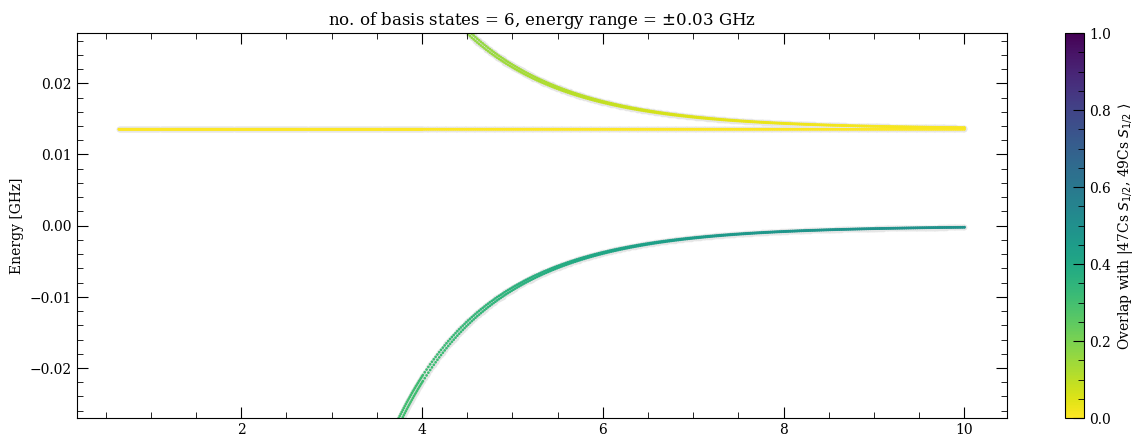

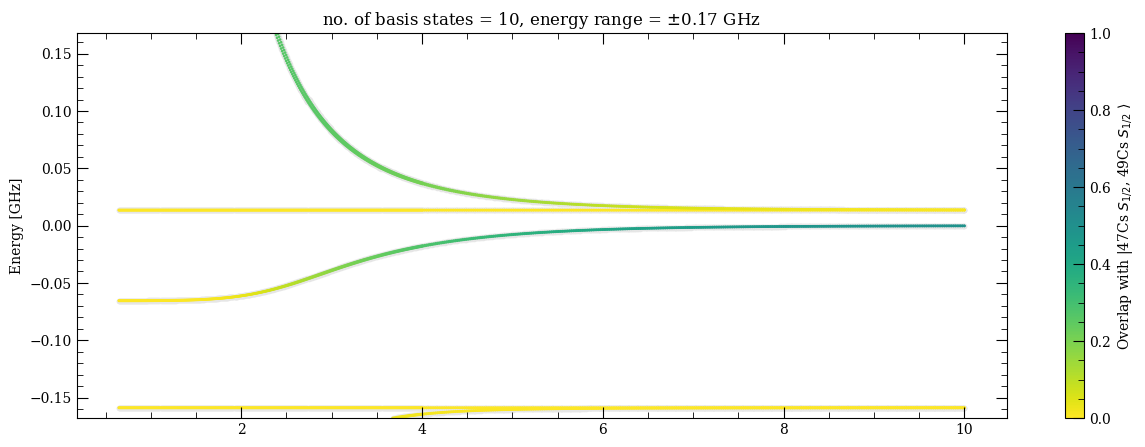

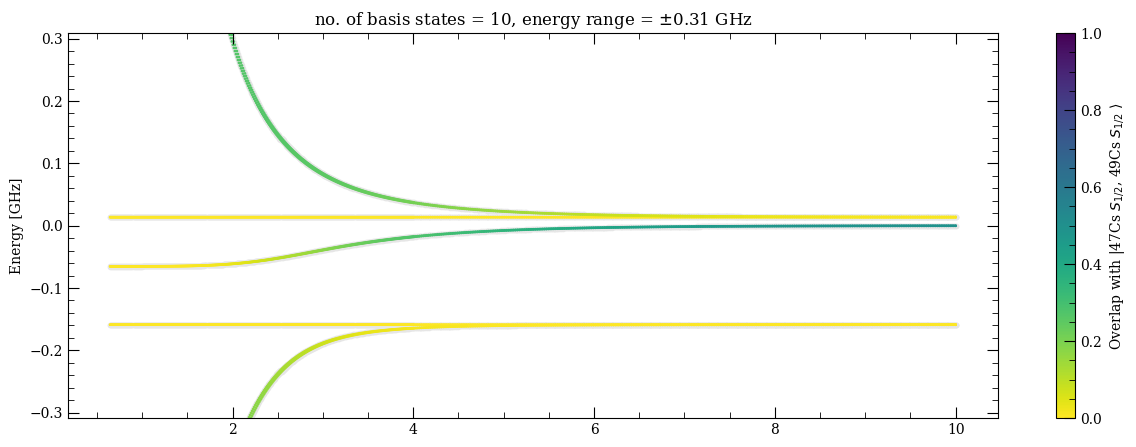

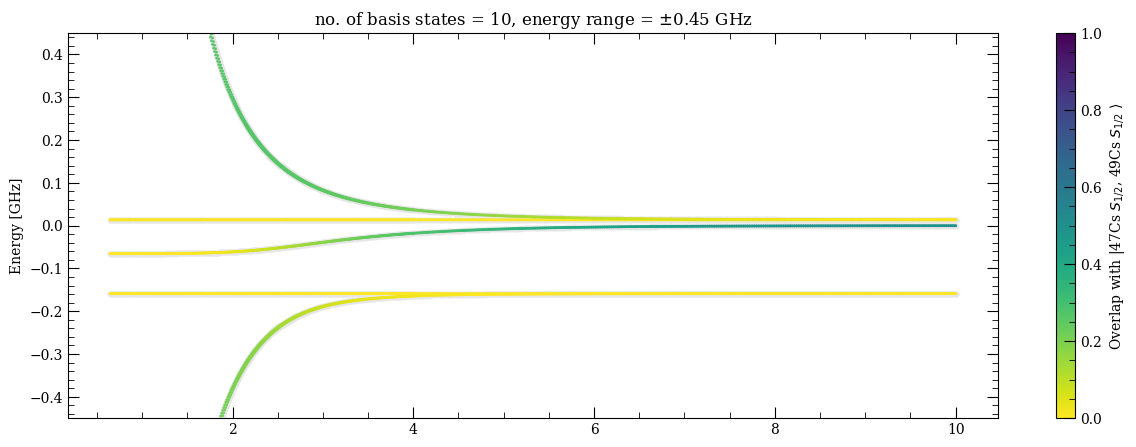

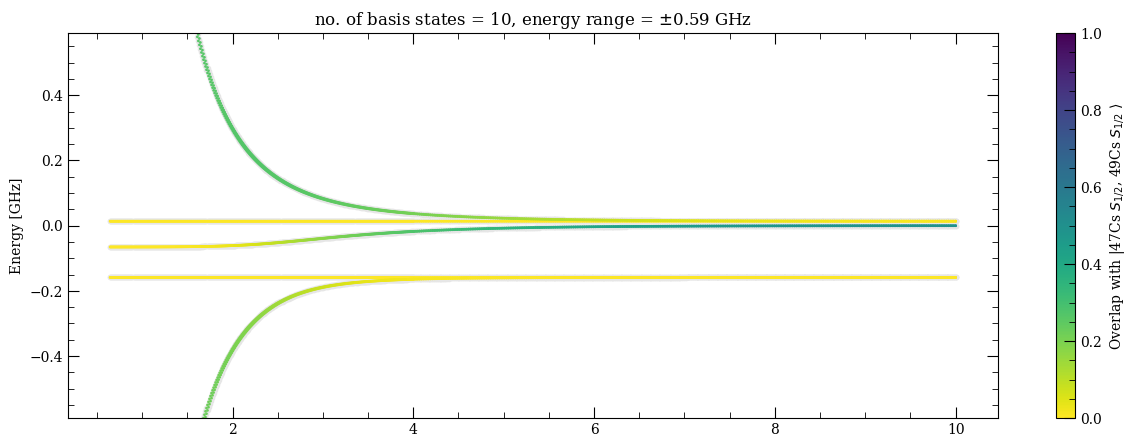

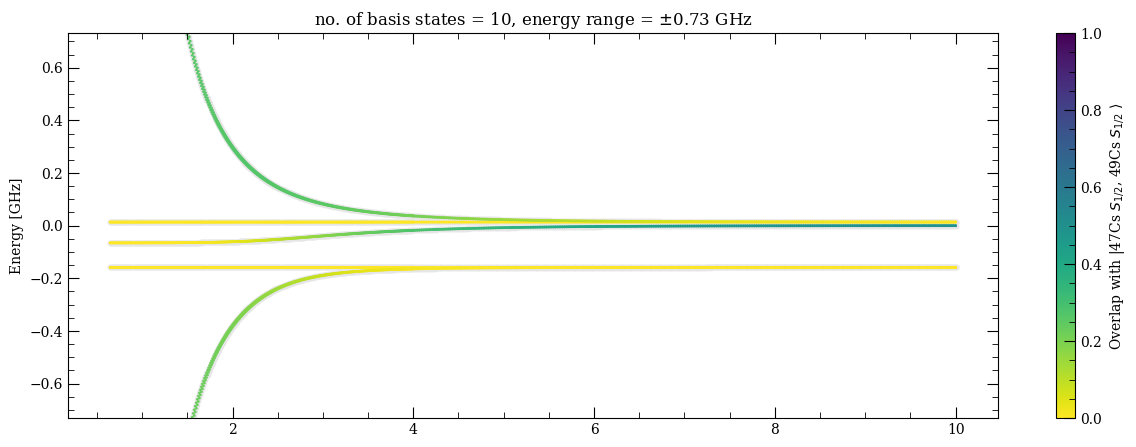

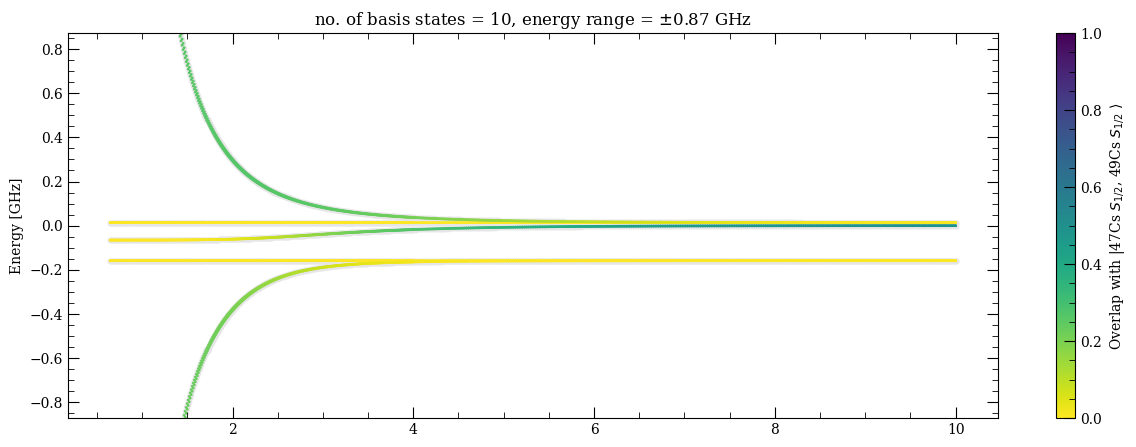

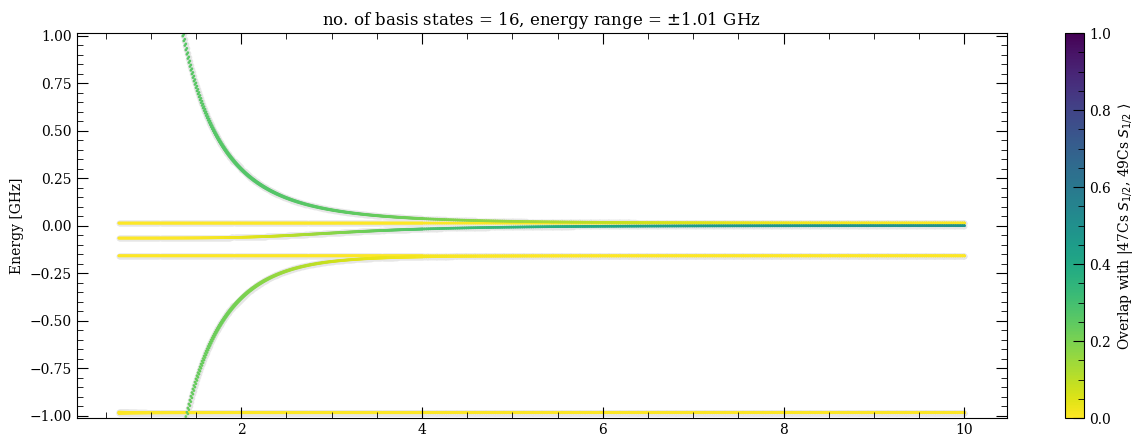

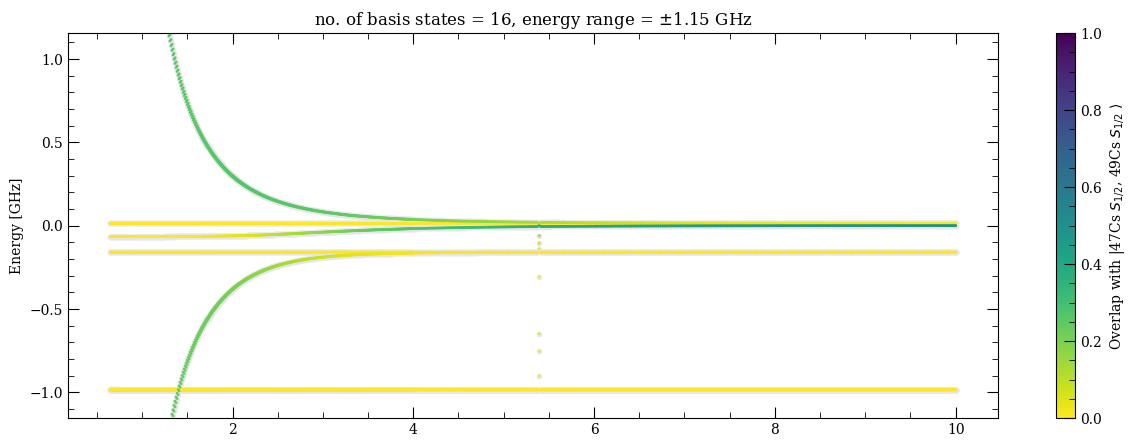

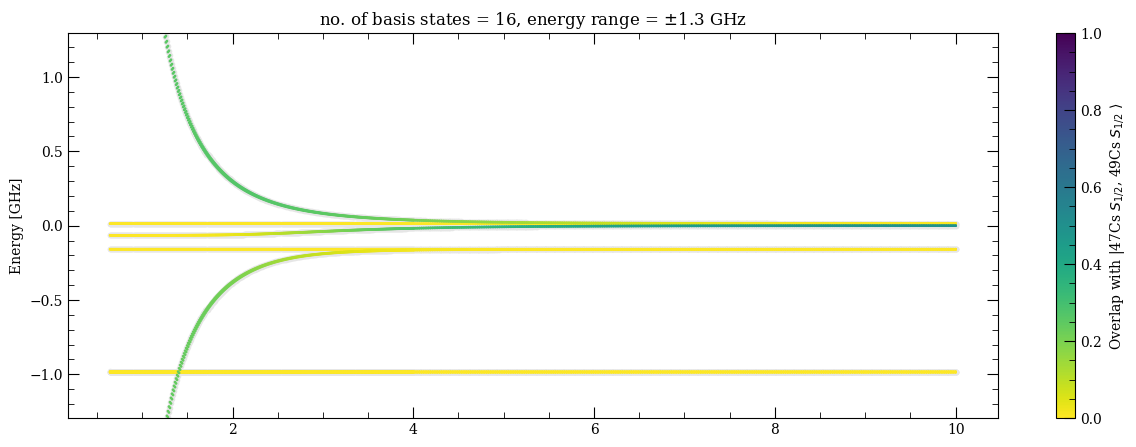

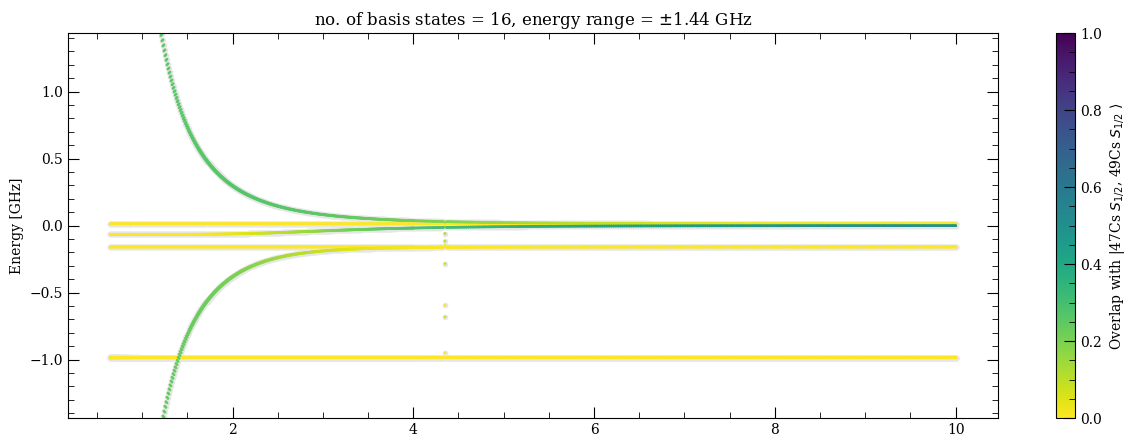

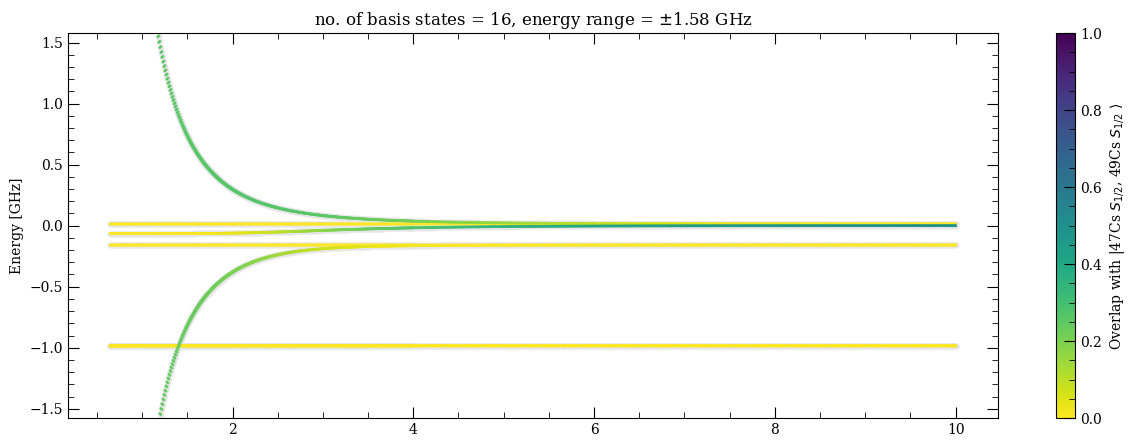

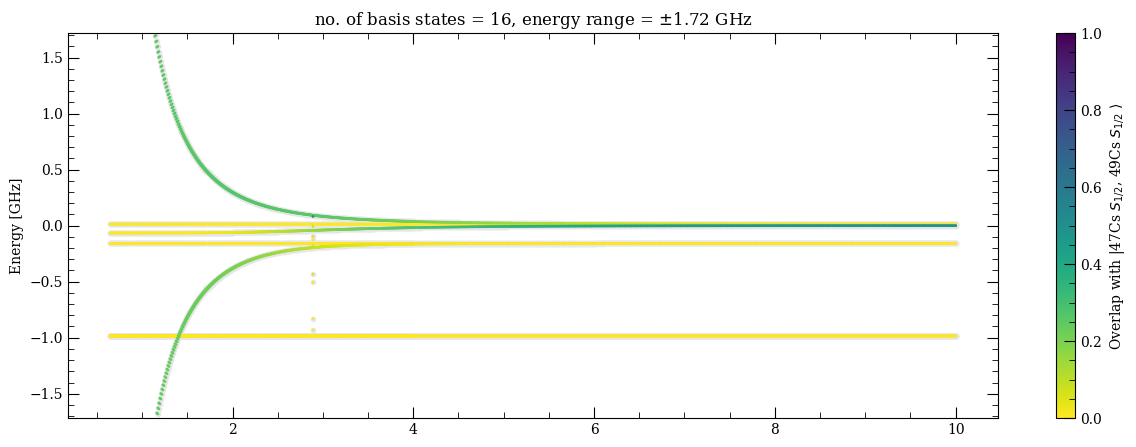

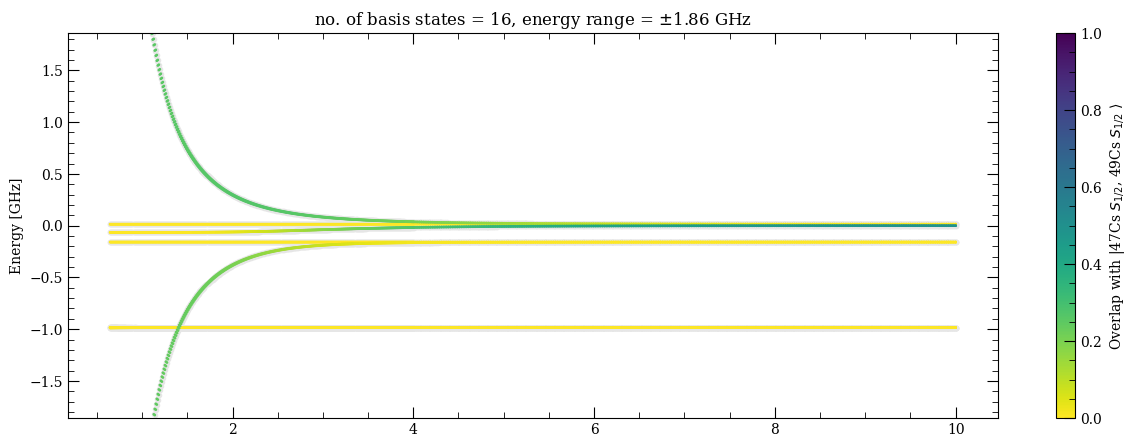

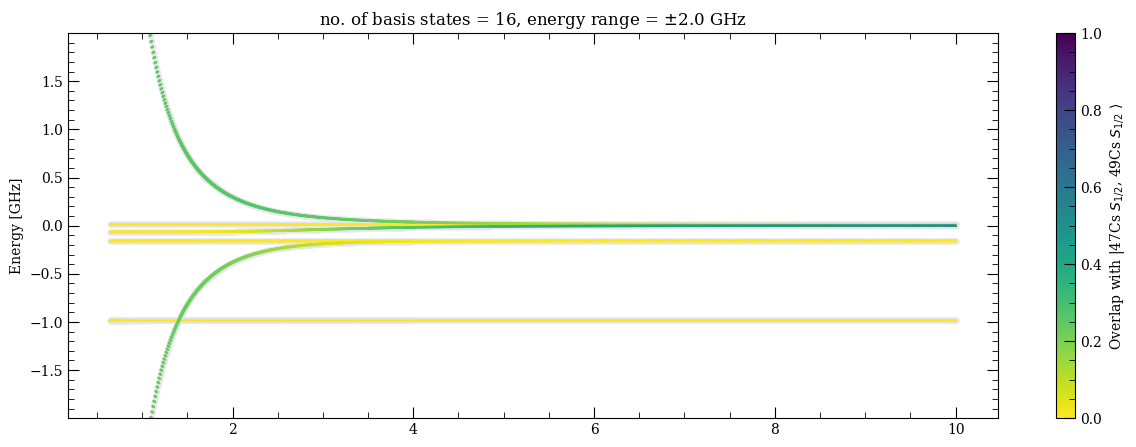

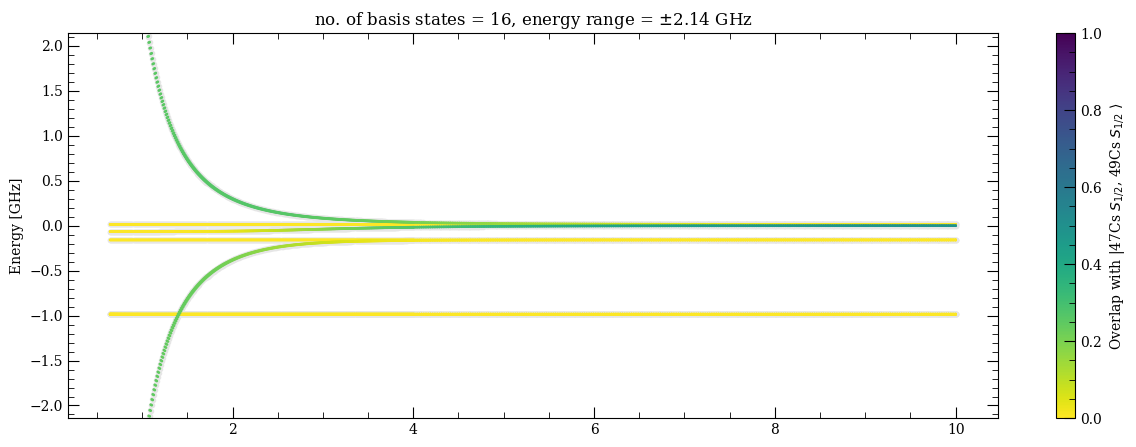

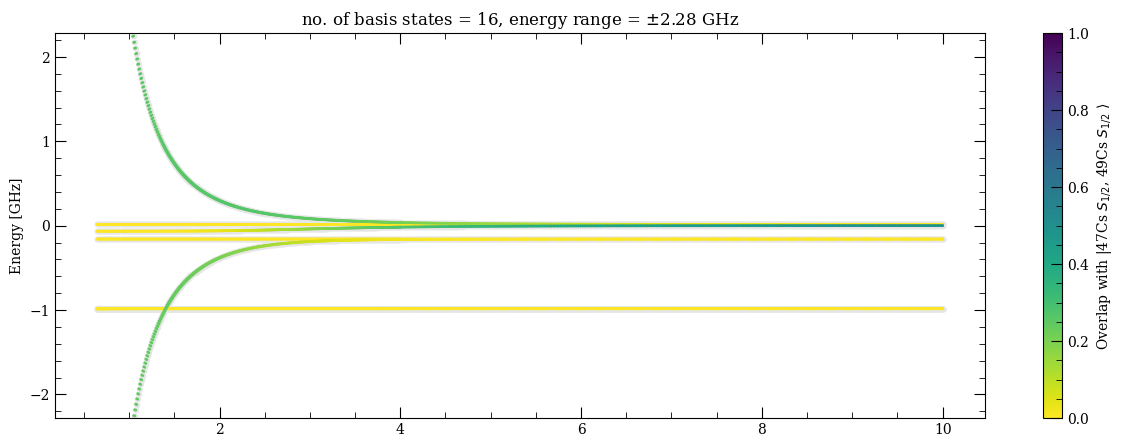

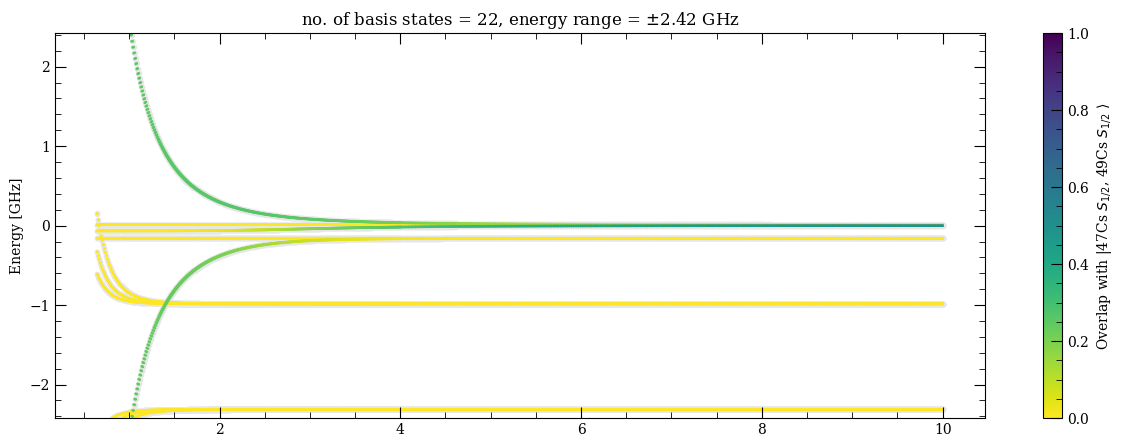

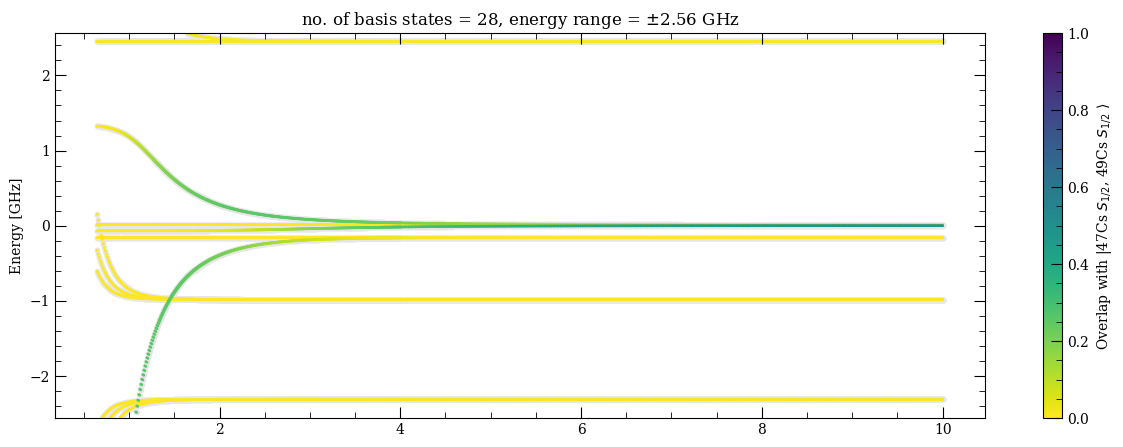

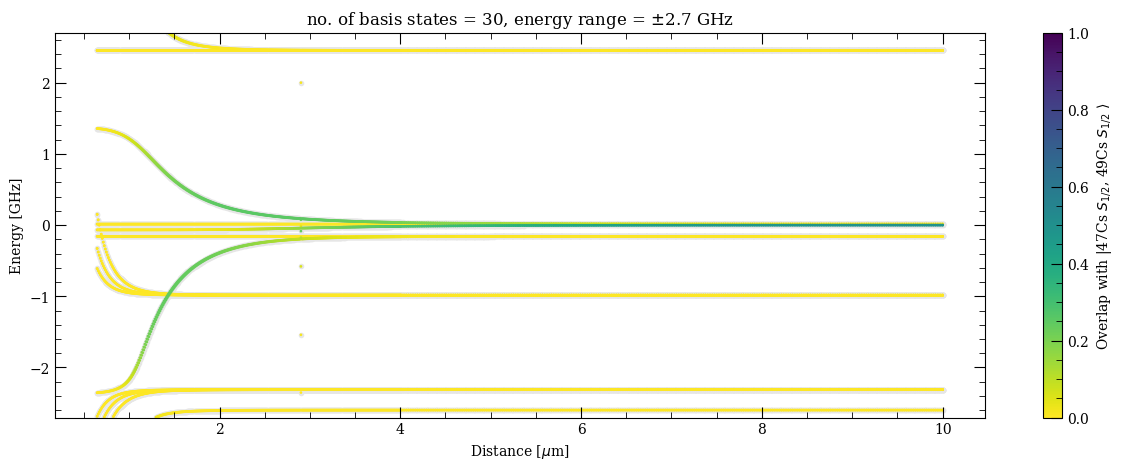

In [35]:
print(c)

newpath = fr'C:\\Users\\tommy_y8q5nfw\\OneDrive - Durham University\\level 4 Project\\Figures\\Fitting C3\\CsCs\\{c['n1_0']}s-{c['n2_0']}s' 
if not os.path.exists(newpath):
    os.makedirs(newpath)

for i in range(len(energy_deltas)):
    fig, ax = plt.subplots(figsize = (15,5))

    
    
    ax.set_ylabel("Energy [GHz]")

    try:
        ax.plot(r, np.array(all_eigenenergies[i]), c="0.9", lw=0.25, zorder=-10)
    except ValueError:  # inhomogeneous shape -> no simple line plot possible
        for x, es in zip(r, all_eigenenergies[i]):
            ax.plot([x] * len(es), es, c="0.9", ls="None", marker=".", zorder=-10)

    x_repeated = np.hstack([val * np.ones_like(es) for val, es in zip(r, all_eigenenergies[i])])
    energies_flattened = np.hstack(all_eigenenergies[i])
    overlaps_flattened = np.hstack(all_overlaps[i])
    sorter = np.argsort(overlaps_flattened)

    scat = ax.scatter(
        x_repeated[sorter],
        energies_flattened[sorter],
        c=overlaps_flattened[sorter],
        s=15,
        vmin=0,
        vmax=1,
        cmap='viridis_r',
        marker = '.',
        linewidths=.001
    )
    ax.set_ylim((-energy_deltas[i], energy_deltas[i]))
    fig.colorbar(scat, ax=ax, label=fr"Overlap with |{c['n1_0']}Cs $S_{{1/2}}$, {c['n2_0']}Cs $S_{{1/2}}$ $\rangle$")
    plt.title(fr'no. of basis states = {num_states[i]}, energy range = $\pm${round(energy_deltas[i],2)} GHz')
    fig.savefig(newpath + f'\\level diagram {num_states[i]}channels')

ax.set_xlabel(r"Distance [$\mu$m]")
plt.show()


[np.int64(50), 0, 0.5, 0.5] [np.int64(47), 0, 0.5, 0.5]


C:\Users\tommy_y8q5nfw\OneDrive - Durham University\level 4 Project\ARC\arc\calculations_atom_pairstate.py:4813: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  self.ax.scatter(


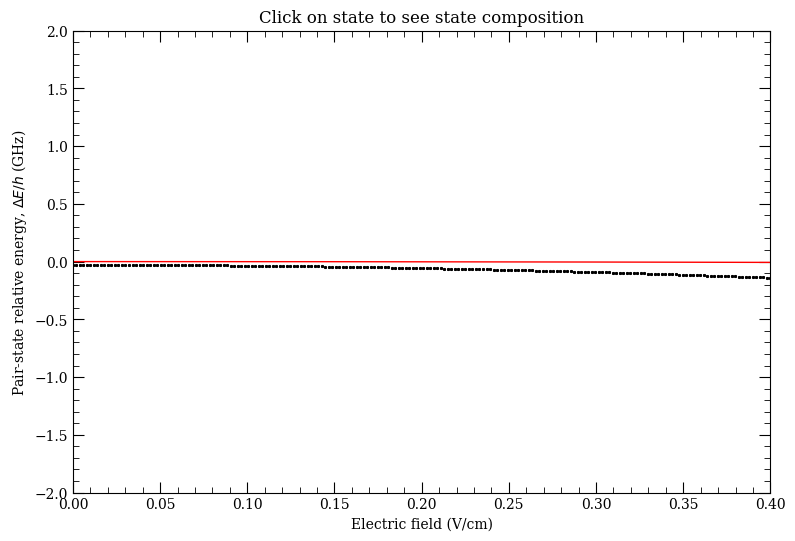

[np.int64(79), 0, 0.5, 0.5] [np.int64(76), 0, 0.5, 0.5]


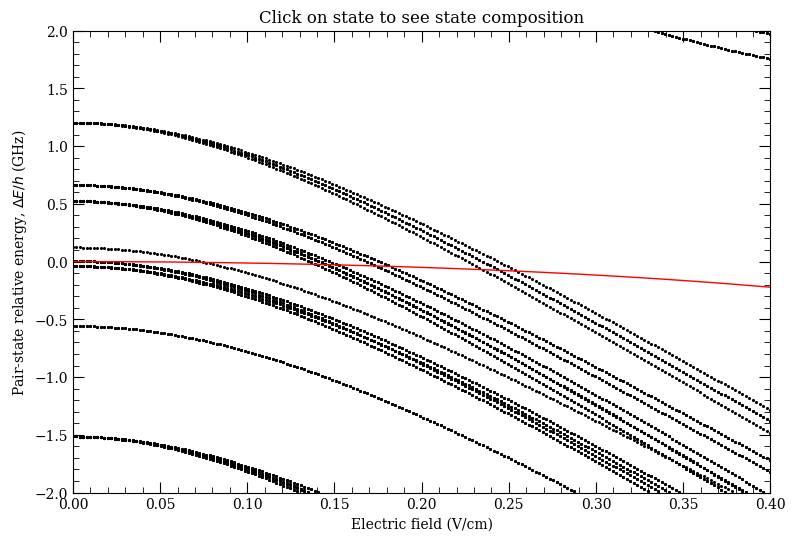

[np.int64(80), 0, 0.5, 0.5] [np.int64(77), 0, 0.5, 0.5]


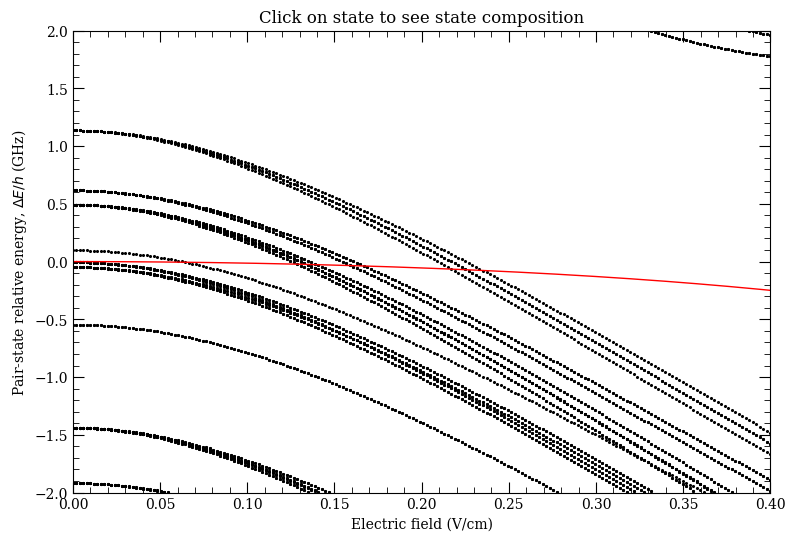

[np.int64(76), 0, 0.5, 0.5] [np.int64(73), 0, 0.5, 0.5]


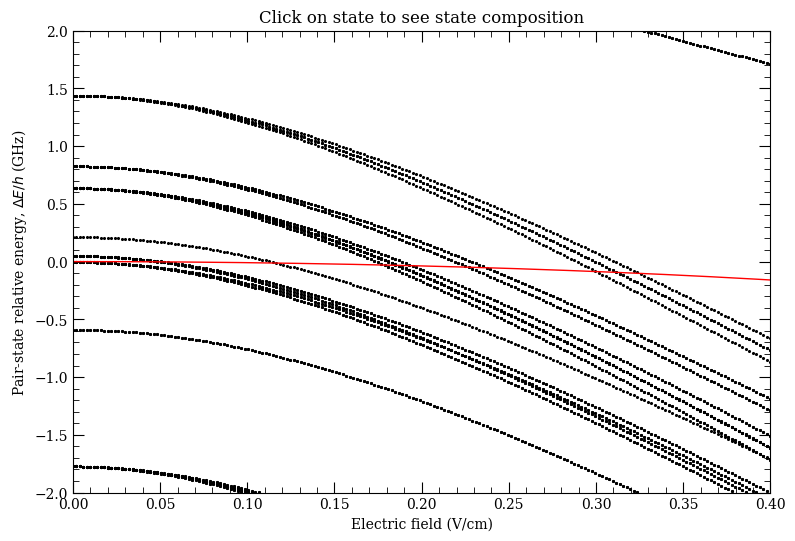

[np.int64(49), 0, 0.5, 0.5] [np.int64(47), 0, 0.5, 0.5]


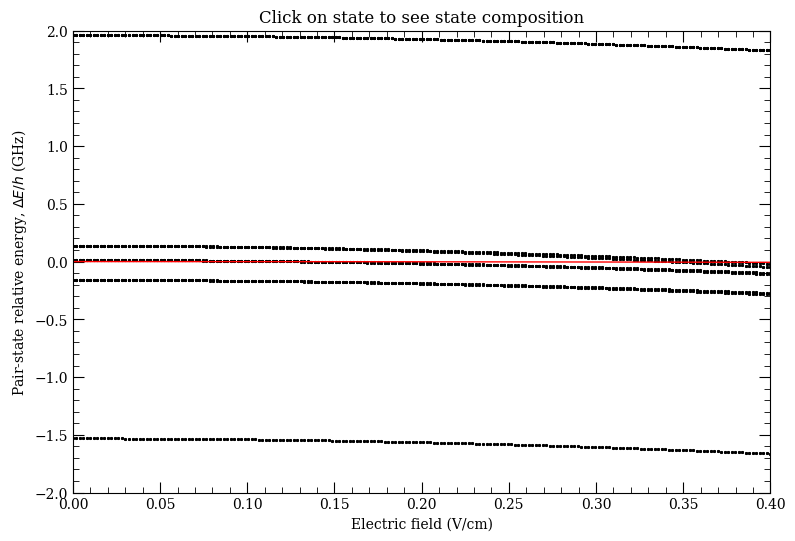

[np.int64(47), 0, 0.5, 0.5] [np.int64(45), 0, 0.5, 0.5]


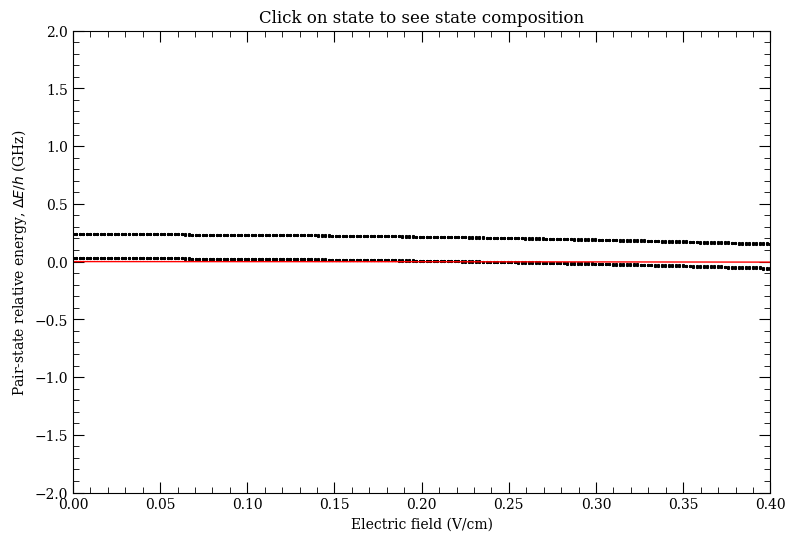

[np.int64(45), 0, 0.5, 0.5] [np.int64(47), 0, 0.5, 0.5]


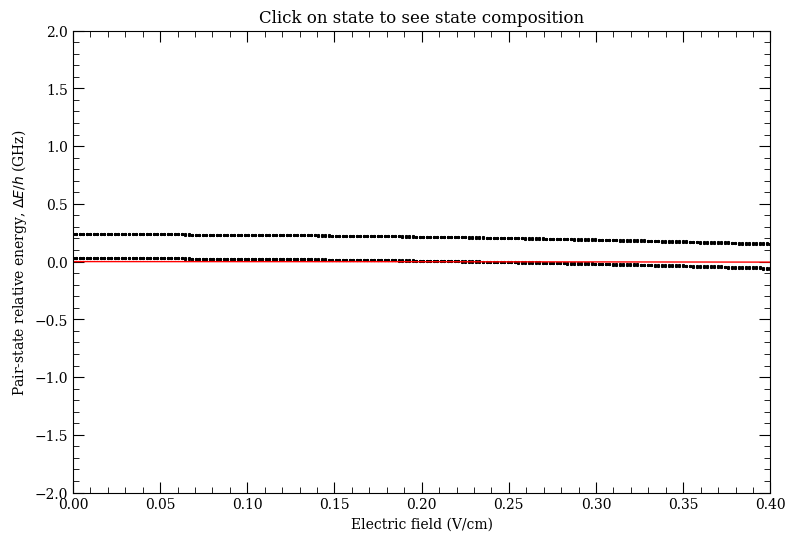

[np.int64(47), 0, 0.5, 0.5] [np.int64(49), 0, 0.5, 0.5]


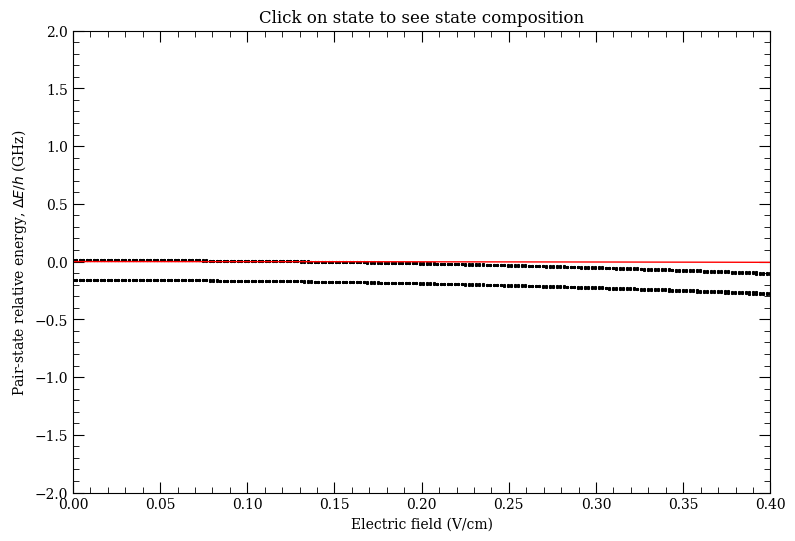

In [ ]:
channel = 4
# Stark Resonances
c = channels[channel-1]
for c in channels:
    newpath = fr'C:\\Users\\tommy_y8q5nfw\\OneDrive - Durham University\\level 4 Project\\Figures\\Stark Plots\\CsCs\\{c[0]}s-{c[3]}s' 
    if not os.path.exists(newpath):
        os.makedirs(newpath)

    state1 = c[0:3]
    state1.append(1/2)
    state2 = c[3:6]
    state2.append(1/2)

    Erange = 2e9
    efield = np.linspace(0,40, 200)
    nrange = 6

    print(state1, state2)
    calc = StarkMapResonances(Caesium(), state1, Caesium(), state2)
    calc.findResonances(state1[0]-nrange, state1[0]+nrange, 5, efield, [-Erange,Erange], Bz=0, progressOutput=False)
    calc.showPlot(interactive=True)
    calc.savePlot(newpath + ' n range = ' + str(nrange))

In [ ]:
# channel = 3
# # Stark Resonances
# c = channels[channel-1]
# calc = StarkMap(Caesium())
# nrange=2
# noOfEigVectors = 5000


# # StarkMapResonances(Caesium(), state1, Caesium(), state2)
# calc.defineBasis(c[0], 0, 1/2, 0.5, c[0]-nrange, c[0]+nrange, 1)

# calc.diagonalise(
#     np.linspace(0, 1e3, noOfEigVectors),
#     progressOutput=True,
# )

# calc.plotLevelDiagram(
#     units=2, highlightState=True, highlightColour="blue", addToExistingPlot=True
# )
# calc.showPlot(interactive=False)
# print(
#     "%.5f MHz cm^2 / V^2 "
#     % calc.getPolarizability(showPlot=True, minStateContribution=0.9)
)

SyntaxError: unmatched ')' (780105658.py, line 24)